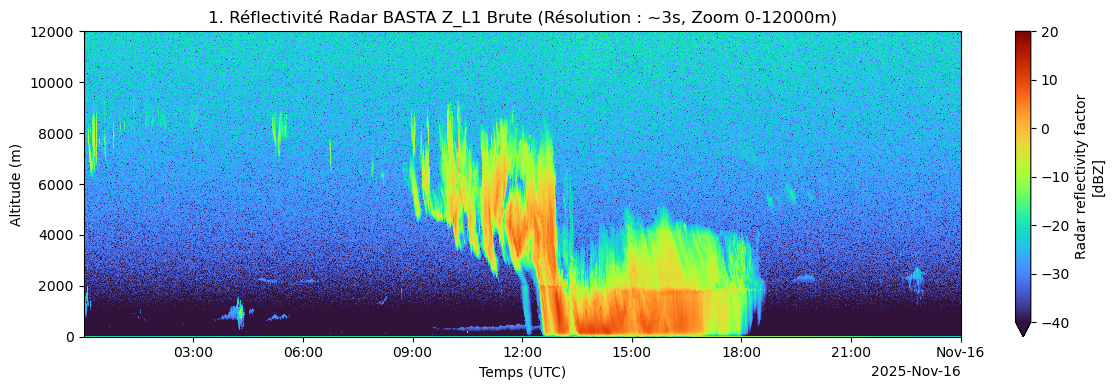

 Dimensions initiales (3s) : (28800, 960)
 Dimensions rééchantillonnées (60s) : (1440, 960)


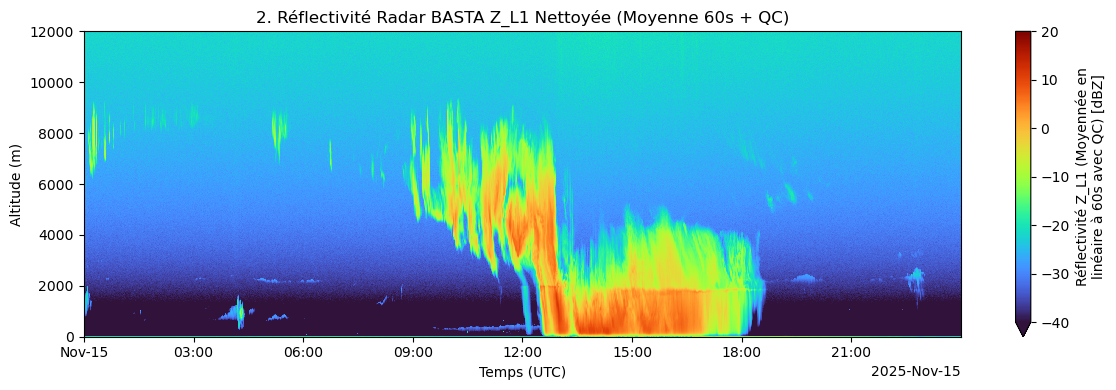

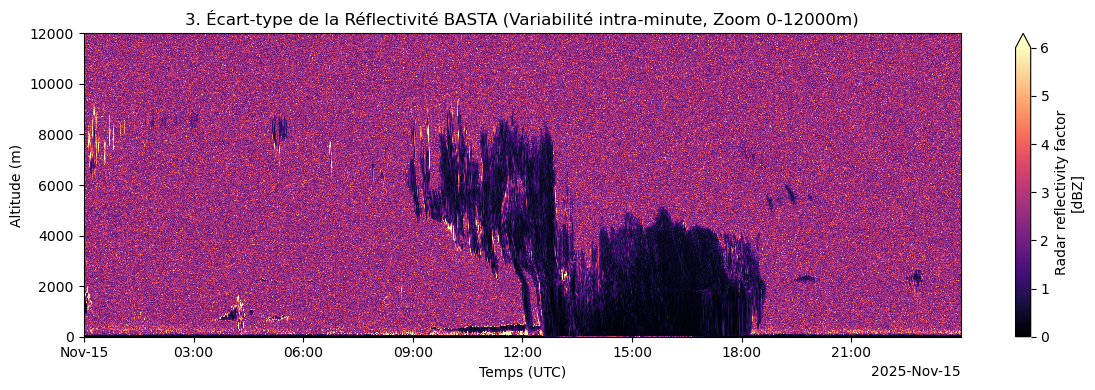

In [2]:
# Calcul de ZL1

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

chemin_fichier = "basta_1a_cldradLz1Lb87R012m_v04_20251115_000000_1440.nc"
ds_basta = xr.open_dataset(chemin_fichier)

Z_L1 = ds_basta["reflectivity"].sel(range=slice(0, 12000)).load()

plt.figure(figsize=(12, 4))
Z_L1.plot(x="time", y="range", cmap="turbo", vmin=-40, vmax=20)
plt.title("1. Réflectivité Radar BASTA Z_L1 Brute (Résolution : ~3s, Zoom 0-12000m)")
plt.ylabel("Altitude (m)")
plt.xlabel("Temps (UTC)")
plt.tight_layout()
plt.show()

Z_L1_lineaire = 10 ** (Z_L1 / 10)
tranches_60s_lin = Z_L1_lineaire.resample(time="1Min")

Z_L1_60s_brut_lin = tranches_60s_lin.mean()
Z_radar_1min_brut = 10 * np.log10(Z_L1_60s_brut_lin)

Z_radar_1min_QC = Z_radar_1min_brut.where(tranches_60s_lin.count() >= 15)

Z_radar_1min_QC.attrs["long_name"] = ("Réflectivité Z_L1 (Moyennée en linéaire à 60s avec QC)")
Z_radar_1min_QC.attrs["units"] = "dBZ"

tranches_60s_dbz = Z_L1.resample(time="1Min")
Z_L1_60s_std = tranches_60s_dbz.std()

print(f" Dimensions initiales (3s) : {Z_L1.shape}")
print(f" Dimensions rééchantillonnées (60s) : {Z_radar_1min_QC.shape}")

plt.figure(figsize=(12, 4))
Z_radar_1min_QC.plot(x="time", y="range", cmap="turbo", vmin=-40, vmax=20)
plt.title("2. Réflectivité Radar BASTA Z_L1 Nettoyée (Moyenne 60s + QC)")
plt.ylabel("Altitude (m)")
plt.xlabel("Temps (UTC)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
Z_L1_60s_std.plot(x="time", y="range", cmap="magma", vmin=0, vmax=6)
plt.title("3. Écart-type de la Réflectivité BASTA (Variabilité intra-minute, Zoom 0-12000m)")
plt.ylabel("Altitude (m)")
plt.xlabel("Temps (UTC)")
plt.tight_layout()
plt.show()

ds_basta.close()

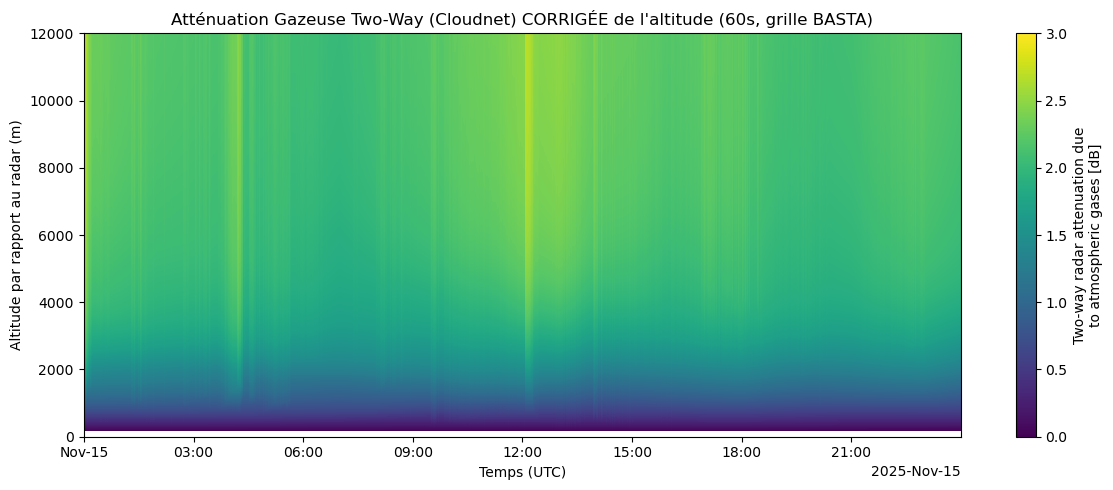

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

chemin_cloudnet = "20251115_palaiseau_categorize.nc"
chemin_basta = "basta_1a_cldradLz1Lb87R012m_v04_20251115_000000_1440.nc"

ds_basta = xr.open_dataset(chemin_basta)
grille_altitude_basta = ds_basta["range"].sel(range=slice(0, 12000)).load()
ds_cloudnet = xr.open_dataset(chemin_cloudnet)

La_brut = ds_cloudnet["radar_gas_atten"]
La_spatial = La_brut.interp(height=grille_altitude_basta)
La_final = La_spatial.resample(time="1Min").mean().load()

La_final.attrs["description"] = ("Atténuation gazeuse double-trajet (Cloudnet) RECALÉE en altitude et rééchantillonnée à 60s")
La_final.attrs["units"] = "dB"

plt.figure(figsize=(12, 5))
La_final.plot(x="time", y="range", cmap="viridis", vmin=0, vmax=3.0)

plt.title("Atténuation Gazeuse Two-Way (Cloudnet) CORRIGÉE de l'altitude (60s, grille BASTA)")
plt.ylabel("Altitude par rapport au radar (m)")
plt.xlabel("Temps (UTC)")
plt.tight_layout()
plt.show()

ds_basta.close()
ds_cloudnet.close()

In [4]:
# Calcul de Lr

def resoudre_mie_goutte(D_mm, lambda_mm, m):
    
    if D_mm <= 0:
        return 0.0

    x = np.pi * D_mm / lambda_mm
    r = D_mm / 2.0
    mx = m * x

    nmax = int(round(x + 4.0 * (x**0.3333) + 2.0))
    nmx = int(max(nmax, np.abs(mx)) + 15)
    
    D = np.zeros(nmx, dtype=complex)
    for n in range(nmx - 2, -1, -1):
        D[n] = (n + 1) / mx - 1.0 / (D[n + 1] + (n + 1) / mx)

    psi = np.zeros(nmax + 1)
    chi = np.zeros(nmax + 1)
    psi[0], chi[0] = np.sin(x), np.cos(x)
    psi[1] = psi[0] / x - np.cos(x)
    chi[1] = chi[0] / x + np.sin(x)

    q_ext = 0.0
    psi_prev2, psi_prev1 = psi[0], psi[1]
    chi_prev2, chi_prev1 = chi[0], chi[1]

    for n in range(1, nmax + 1):
        if n > 1:
            psi_n = ((2 * n - 1) / x) * psi_prev1 - psi_prev2
            chi_n = ((2 * n - 1) / x) * chi_prev1 - chi_prev2
        else:
            psi_n, chi_n = psi[1], chi[1]

        xi_n = complex(psi_n, -chi_n)
        xi_prev = (
            complex(psi_prev1, -chi_prev1) if n > 1 else complex(psi[0], -chi[0])
        )
        sub_psi = psi_prev1 if n > 1 else psi[0]

        an = (((D[n] / m) + (n / x)) * psi_n - sub_psi) / (
            ((D[n] / m) + (n / x)) * xi_n - xi_prev
        )
        bn = ((m * D[n] + (n / x)) * psi_n - sub_psi) / (
            (m * D[n] + (n / x)) * xi_n - xi_prev
        )

        q_ext += (2 * n + 1) * (an.real + bn.real)

        if n > 1:
            psi_prev2, psi_prev1 = psi_prev1, psi_n
            chi_prev2, chi_prev1 = chi_prev1, chi_n

    Qext = (2.0 / x**2) * q_ext
    aire_goutte = np.pi * (r**2)
    return Qext * aire_goutte

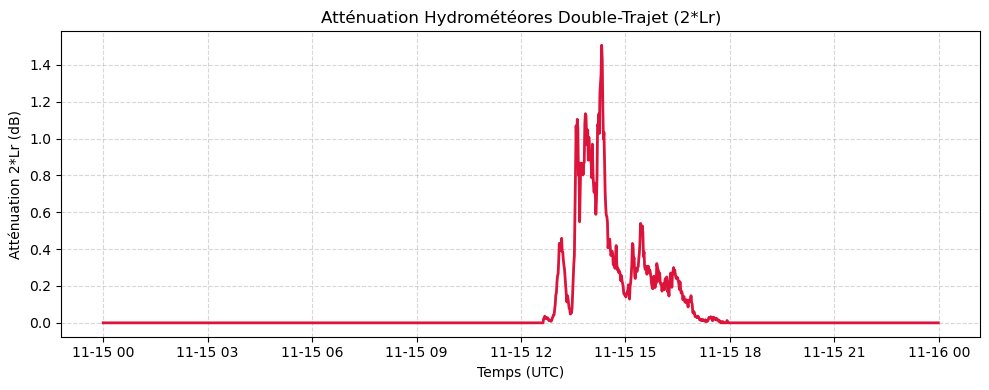

In [7]:
# Calcul de La

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.ticker as ticker

chemin_file = "spectropluvio_1a_Lz1LpnF60secPrainratePsize_v01_20251115_000000_1440.nc"
ds_disdro = xr.open_dataset(chemin_file)
ds_disdro['Z'] = ds_disdro['Z'].where(ds_disdro['Z'] > -9.99)

diametres = ds_disdro["size_classes"].values  
dD = ds_disdro.coords.get("delta_D", 1.0)     
frequence_ghz = 95.0
longueur_onde_mm = 299.792 / frequence_ghz
m_eau = complex(3.2, 1.8) 

sigma_ext_mie = np.array([resoudre_mie_goutte(D, longueur_onde_mm, m_eau) for D in diametres])
sigma_ext_xr = xr.DataArray(sigma_ext_mie, dims=["size_classes"], coords={"size_classes": ds_disdro["size_classes"]})

produit_intermediaire = sigma_ext_xr * ds_disdro["psd"] * dD
somme_spectrale = produit_intermediaire.sum(dim=["size_classes", "speed_classes"])
k_mie = 4.343e3 * somme_spectrale * 2.27e-8
Lr_double_final = 2 * (k_mie * 0.2)

Z_disdro_aligned = ds_disdro['Z'].reindex(time=Z_L2_corr_200m.time, method='nearest')
wra_da = Z_disdro_aligned - Z_L2_corr_200m
rainrate_aligned = ds_disdro['pr'].reindex(time=Z_L2_corr_200m.time, method='nearest')

df_fit = pd.DataFrame({'WRA': wra_da.values,'Rainrate': rainrate_aligned.values})
df_clean = df_fit[df_fit['Rainrate'] > 0.1].copy()
df_clean['log_R'] = np.log10(df_clean['Rainrate'])

plt.figure(figsize=(10, 4))
plt.plot(Lr_double_final.time, Lr_double_final, color="crimson", lw=2)
plt.title("Atténuation Hydrométéores Double-Trajet (2*Lr)")
plt.ylabel("Atténuation 2*Lr (dB)")
plt.xlabel("Temps (UTC)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

ds_disdro.close()

In [8]:
# Calcul de ZL2 corr

import pandas as pd
import xarray as xr

Z_radar_200m = Z_radar_1min_QC.sel(range=200, method="nearest")
La_200m_brut = (La_spatial.sel(range=200, method="nearest").resample(time="1Min").mean())
Lr_200m_brut = Lr_double_final

La_200m_aligne = La_200m_brut.reindex(time=Z_radar_200m["time"], method="nearest")
Lr_200m_aligne = Lr_200m_brut.reindex(time=Z_radar_200m["time"], method="nearest")
rainrate_brut = ds_disdro["pr"]
rainrate_aligne = rainrate_brut.reindex(time=Z_radar_200m["time"], method="nearest")

val_radar = Z_radar_200m.values
val_gaz = La_200m_aligne.values
val_pluie = Lr_200m_aligne.values
val_rainrate = rainrate_aligne.values

val_Z_L2_corr = val_radar + val_gaz + val_pluie
Z_L2_corr_200m = xr.DataArray(val_Z_L2_corr, dims=["time"], coords={"time": Z_radar_200m["time"]})

df_controle = pd.DataFrame({"Z_brut_200m (dBZ)": val_radar, "2La_gaz_200m (dB)": val_gaz, "2Lr_pluie_200m (dB)": val_pluie,
                            "Rainrate (mm/h)": val_rainrate, "Z_L2_corr_200m (dBZ)": val_Z_L2_corr,}, index=Z_radar_200m["time"].values)

print(df_controle.loc["2025-11-15 15:00:00":"2025-11-15 16:05:00"])

                     Z_brut_200m (dBZ)  2La_gaz_200m (dB)  \
2025-11-15 15:00:00           3.085034           0.059653   
2025-11-15 15:01:00           3.030216           0.059985   
2025-11-15 15:02:00           3.350030           0.058713   
2025-11-15 15:03:00           2.355788           0.058714   
2025-11-15 15:04:00           2.515337           0.058715   
...                                ...                ...   
2025-11-15 16:01:00           4.125127           0.058811   
2025-11-15 16:02:00           3.199687           0.058826   
2025-11-15 16:03:00           3.272263           0.058840   
2025-11-15 16:04:00           3.878214           0.058854   
2025-11-15 16:05:00           2.528100           0.061189   

                     2Lr_pluie_200m (dB)  Rainrate (mm/h)  \
2025-11-15 15:00:00             0.144089         0.437500   
2025-11-15 15:01:00             0.140491         0.406250   
2025-11-15 15:02:00             0.158600         0.492188   
2025-11-15 15:03:00    

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

Z_disdro_brut = ds_disdro["Z"]
Z_disdro_aligne = Z_disdro_brut.reindex(time=Z_radar_200m["time"], method="nearest")
val_Z_disdro = Z_disdro_aligne.values

val_WRA = val_Z_disdro - val_Z_L2_corr

df_controle["Z_disdro (dBZ)"] = val_Z_disdro
df_controle["WRA (dB)"] = val_WRA

colonnes_ordre = ["Rainrate (mm/h)","Z_brut_200m (dBZ)","2La_gaz_200m (dB)","2Lr_pluie_200m (dB)","Z_L2_corr_200m (dBZ)","Z_disdro (dBZ)","WRA (dB)",]

print(df_controle[colonnes_ordre].loc["2025-11-15 16:00:00":"2025-11-15 17:05:00"])

                     Rainrate (mm/h)  Z_brut_200m (dBZ)  2La_gaz_200m (dB)  \
2025-11-15 16:00:00         0.726562           4.882610           0.058797   
2025-11-15 16:01:00         0.679688           4.125127           0.058811   
2025-11-15 16:02:00         0.679688           3.199687           0.058826   
2025-11-15 16:03:00         0.578125           3.272263           0.058840   
2025-11-15 16:04:00         0.687500           3.878214           0.058854   
...                              ...                ...                ...   
2025-11-15 17:01:00         0.078125          -5.681506           0.059619   
2025-11-15 17:02:00         0.078125          -5.594995           0.059602   
2025-11-15 17:03:00         0.062500          -5.175434           0.061121   
2025-11-15 17:04:00         0.085938          -5.944314           0.059568   
2025-11-15 17:05:00         0.078125          -7.326500           0.060319   

                     2Lr_pluie_200m (dB)  Z_L2_corr_200m (dBZ) 

In [9]:
# Vérifier rigoureusement les valeurs à 0 m (au niveau du radôme) pour s'assurer que le vecteur commence bien à 0 et ne contient pas d'erreurs.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

Z_disdro_zoom = ds_disdro["Z"].sel(time=slice("2025-11-15 08:00:00", "2025-11-15 09:00:00"))

nb_total = len(Z_disdro_zoom.time)
nb_nans = Z_disdro_zoom.isnull().sum().values
nb_valides = Z_disdro_zoom.notnull().sum().values
val_min = Z_disdro_zoom.min().values
val_max = Z_disdro_zoom.max().values

print(f"-> Nombre total de points temporels : {nb_total}")
print(f"-> Points valides                   : {nb_valides} ({nb_valides/nb_total*100:.1f}%)")
print(f"-> Points en erreur/NaN             : {nb_nans}")
print(f"-> Gamme des valeurs mesurées (dBZ) : {val_min:.2f} dBZ à {val_max:.2f} dBZ")

print("\n--- APERÇU DES 10 PREMIÈRES MINUTES ---")
print(Z_disdro_zoom.to_series().head(10))

-> Nombre total de points temporels : 61
-> Points valides                   : 0 (0.0%)
-> Points en erreur/NaN             : 61
-> Gamme des valeurs mesurées (dBZ) : nan dBZ à nan dBZ

--- APERÇU DES 10 PREMIÈRES MINUTES ---
time
2025-11-15 08:00:00   NaN
2025-11-15 08:01:00   NaN
2025-11-15 08:02:00   NaN
2025-11-15 08:03:00   NaN
2025-11-15 08:04:00   NaN
2025-11-15 08:05:00   NaN
2025-11-15 08:06:00   NaN
2025-11-15 08:07:00   NaN
2025-11-15 08:08:00   NaN
2025-11-15 08:09:00   NaN
Name: Z, dtype: float32


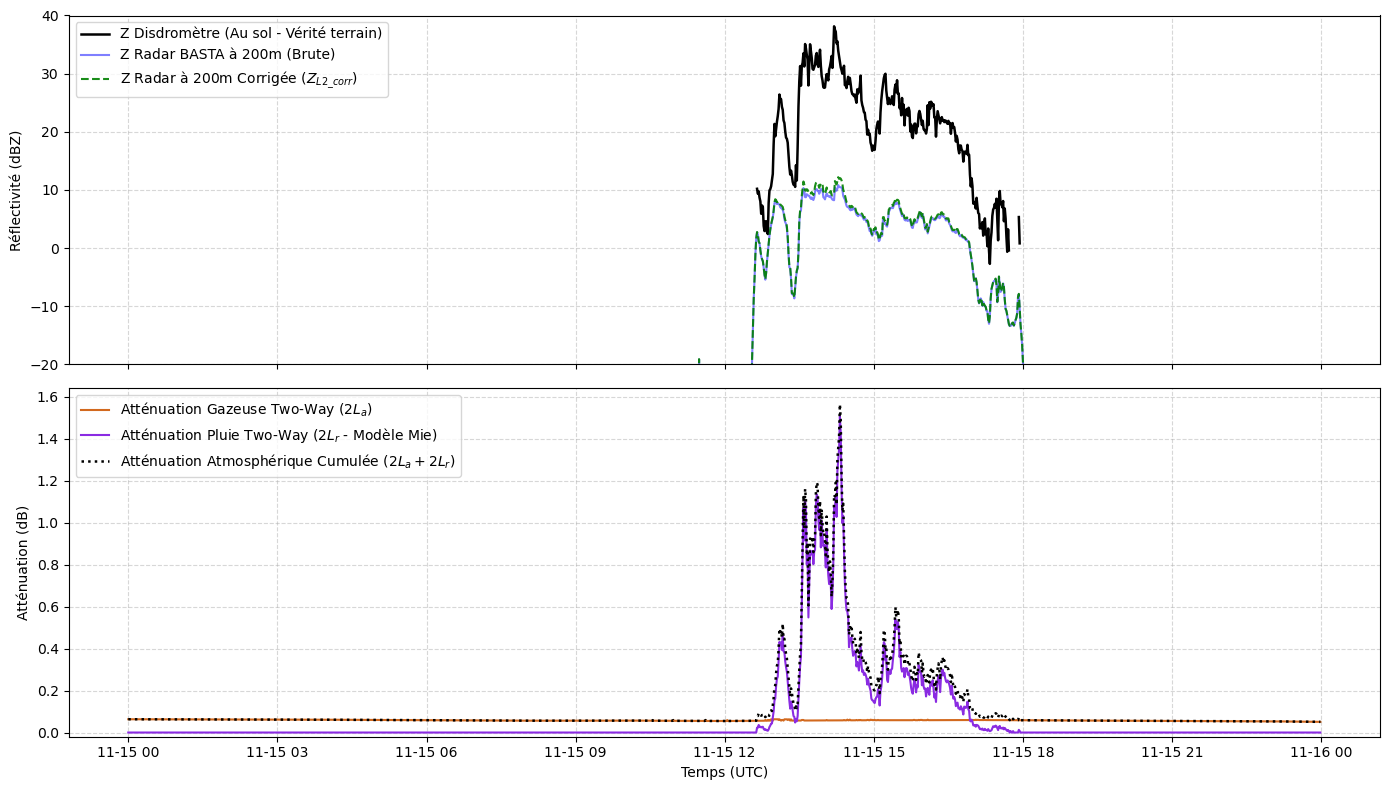

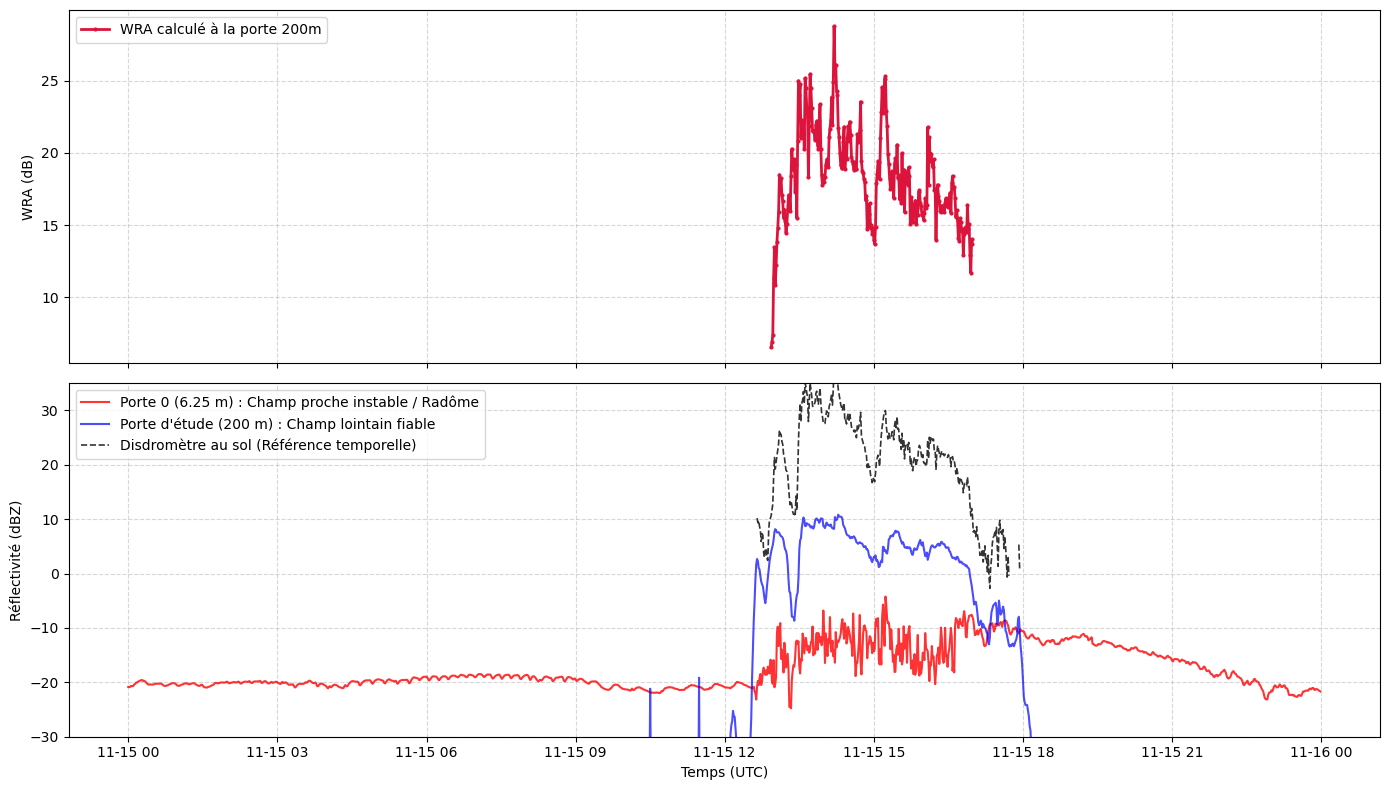

In [13]:
# Graphique finaux

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

temps = Z_radar_1min_QC.time
Z_radar_200m_brute = Z_radar_1min_QC.sel(range=200, method="nearest")
Z_disdro_aligne = ds_disdro["Z"].reindex(time=temps, method="nearest")

La_200m_aligne = (La_spatial.sel(range=200, method="nearest").resample(time="1Min").mean().reindex(time=temps, method="nearest"))
Lr_200m_aligne = Lr_double_final.reindex(time=temps, method="nearest")
L_total_atm = La_200m_aligne + Lr_200m_aligne

val_Z_L2_corr = Z_L2_corr_200m.values
val_Z_disdro = Z_disdro_aligne.values
val_WRA = val_Z_disdro - val_Z_L2_corr
val_rainrate = (ds_disdro["pr"].reindex(time=temps, method="nearest").values)


fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(temps, Z_disdro_aligne, label="Z Disdromètre (Au sol - Vérité terrain)", color="black", linewidth=1.8)
ax1.plot(temps, Z_radar_200m_brute, label="Z Radar BASTA à 200m (Brute)", color="blue", alpha=0.5)
ax1.plot(temps, Z_L2_corr_200m, label="Z Radar à 200m Corrigée ($Z_{L2\\_corr}$)", color="green", linestyle="--", alpha=0.9)
ax1.set_ylabel("Réflectivité (dBZ)")
ax1.set_ylim(-20, 40)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

ax2.plot(temps, La_200m_aligne, label="Atténuation Gazeuse Two-Way ($2L_a$)", color="chocolate", linewidth=1.5)
ax2.plot(temps, Lr_200m_aligne, label="Atténuation Pluie Two-Way ($2L_r$ - Modèle Mie)", color="blueviolet", linewidth=1.5)
ax2.plot(temps, L_total_atm, label="Atténuation Atmosphérique Cumulée ($2L_a + 2L_r$)", color="black", linestyle=":", linewidth=1.8)
ax2.set_ylabel("Atténuation (dB)")
ax2.set_xlabel("Temps (UTC)")
ax2.set_ylim(bottom=-0.02)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

WRA_xr = xr.DataArray(val_WRA, dims=["time"], coords={"time": temps})
WRA_filtre = WRA_xr.where(val_rainrate > 0.1)

ax3.plot(temps, WRA_filtre, color="crimson", linewidth=2, marker="o", markersize=2, label="WRA calculé à la porte 200m")
ax3.set_ylabel("WRA (dB)")
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper left")

Z_radar_6m = Z_radar_1min_QC.isel(range=0)

ax4.plot(temps, Z_radar_6m, label="Porte 0 (6.25 m) : Champ proche instable / Radôme", color="red", linewidth=1.5, alpha=0.8)
ax4.plot(temps, Z_radar_200m_brute, label="Porte d'étude (200 m) : Champ lointain fiable", color="blue", linewidth=1.5, alpha=0.7)
ax4.plot(temps, Z_disdro_aligne, label="Disdromètre au sol (Référence temporelle)", color="black", linestyle="--", linewidth=1.2, alpha=0.8)
ax4.set_ylabel("Réflectivité (dBZ)")
ax4.set_xlabel("Temps (UTC)")
ax4.set_ylim(-30, 35)
ax4.grid(True, linestyle="--", alpha=0.5)
ax4.legend(loc="upper left")

plt.tight_layout()
plt.show()

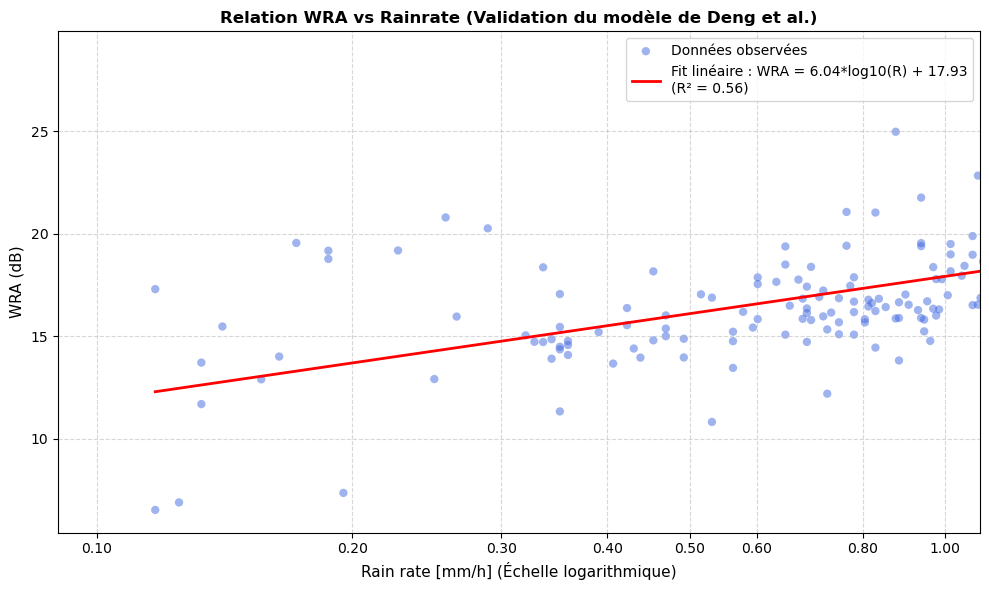

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from scipy.stats import linregress

df_fit = pd.DataFrame({'WRA': val_WRA,'Rainrate': val_rainrate})
df_clean = df_fit[df_fit['Rainrate'] > 0.1].copy()
df_clean['log_R'] = np.log10(df_clean['Rainrate'])

slope, intercept, r_value, p_value, std_err = linregress(df_clean['log_R'], df_clean['WRA'])

x_fit = np.linspace(df_clean['log_R'].min(), df_clean['log_R'].max(), 100)
y_fit = intercept + slope * x_fit

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['log_R'], df_clean['WRA'], alpha=0.5, color='royalblue', edgecolors='none', label='Données observées')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Fit linéaire : WRA = {slope:.2f}*log10(R) + {intercept:.2f}\n(R² = {r_value**2:.2f})')
plt.title("Relation WRA vs Rainrate (Validation du modèle de Deng et al.)", fontsize=12, fontweight='bold')
plt.xlabel("Rain rate [mm/h] (Échelle logarithmique)", fontsize=11)
plt.ylabel("WRA (dB)", fontsize=11)

ax = plt.gca()
ticks_physiques = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])

ax.set_xticks(np.log10(ticks_physiques))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{10**x:.2f}'))

plt.xlim(np.log10(0.09), np.log10(1.1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()